# Modelado de `valor_eur`

Partimos de `fbref_tm_features.parquet` (de `03-ingenieria_variables.ipynb`). Ya todo está en dummies excepto `Squad` (130 equipos) -- lo dejamos sin codificar a propósito, porque el target encoding que le vamos a aplicar usa el objetivo, y calcularlo antes de separar train/test filtraría información del test hacia el train.

Por eso el orden acá es: primero separamos train/test **por `player_id`**, y recién después ajustamos el target encoding de `Squad` solo con el train.

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import TargetEncoder

pd.set_option('display.max_columns', None)

In [2]:
df = pd.read_parquet("../data/processed/fbref_tm_features.parquet")
print(f"Shape: {df.shape}")
df.dtypes.value_counts()

Shape: (13023, 65)


int64      35
float64    27
str         3
Name: count, dtype: int64

## 1. Split train/test por `player_id`

Separamos los `player_id` únicos antes de filtrar filas, para que todas las temporadas de un mismo jugador queden del mismo lado.

In [3]:
TARGET = "log_valor_eur"

player_ids = df["player_id"].unique().to_numpy()
train_ids, test_ids = train_test_split(player_ids, test_size=0.2, random_state=42)

df_train = df[df["player_id"].isin(train_ids)].copy()
df_test = df[df["player_id"].isin(test_ids)].copy()

print(f"Train: {df_train.shape[0]} filas, {df_train['player_id'].nunique()} jugadores")
print(f"Test:  {df_test.shape[0]} filas, {df_test['player_id'].nunique()} jugadores")
print(f"Jugadores en ambos conjuntos: {len(set(train_ids) & set(test_ids))}")

Train: 10352 filas, 4331 jugadores
Test:  2671 filas, 1083 jugadores
Jugadores en ambos conjuntos: 0


## 2. Target encoding de `Squad` (solo con train)

`TargetEncoder` de sklearn cambia cada equipo por una media de `log_valor_eur` suavizada hacia la media global (mismo mean encoding que decidimos en `03`). Además hace *cross-fitting* interno para que ninguna fila use su propio target al codificarse.

Lo importante para no filtrar información: `fit_transform` va solo en train, y test solo recibe `transform` -- ninguna media usada en test sale de datos del propio test.

In [4]:
encoder = TargetEncoder(
    target_type="continuous",
    cv=KFold(n_splits=5, shuffle=True, random_state=42),
)

df_train["Squad_target_enc"] = encoder.fit_transform(
    df_train[["Squad"]], df_train[TARGET]
).ravel()
df_test["Squad_target_enc"] = encoder.transform(df_test[["Squad"]]).ravel()

df_train = df_train.drop(columns=["Squad"])
df_test = df_test.drop(columns=["Squad"])

print(f"Equipos vistos en train: {len(encoder.categories_[0])}")
df_train[["Squad_target_enc"]].describe()

Equipos vistos en train: 130


,Squad_target_enc
count,10352.000000
mean,6.644825
std,0.345993
min,5.558113
25%,6.352611
50%,6.638643
75%,6.921525
max,7.528226


## 3. Regresión lineal simple (punto de partida)

Antes de complicarnos, entrenamos una regresión lineal sin regularizar sobre todas las features, para tener una referencia de cuánta señal hay y dónde falla lo más simple posible.

Predecimos `log_valor_eur`, no `valor_eur` (muy sesgado, como vimos en el EDA). Sacamos los identificadores y `valor_eur` crudo (sería fuga directa, es literalmente el mismo número sin el logaritmo).

In [5]:
ID_COLS = ["Player", "player_id", "saison_id"]
TARGET_COLS = ["valor_eur", "log_valor_eur"]

feature_cols = [c for c in df_train.columns if c not in ID_COLS + TARGET_COLS]

X_train, y_train = df_train[feature_cols], df_train[TARGET]
X_test, y_test = df_test[feature_cols], df_test[TARGET]

print(f"Features usadas: {len(feature_cols)}")
print(f"Tipos de dato en X_train:\n{X_train.dtypes.value_counts()}")

Features usadas: 60
Tipos de dato en X_train:
int64      34
float64    26
Name: count, dtype: int64


In [6]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)

pred_train = lr.predict(X_train)
pred_test = lr.predict(X_test)

In [7]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error


def evaluar(y_true_log, y_pred_log, nombre):
    r2 = r2_score(y_true_log, y_pred_log)
    rmse_log = mean_squared_error(y_true_log, y_pred_log) ** 0.5
    mae_log = mean_absolute_error(y_true_log, y_pred_log)

    # log_valor_eur = log10(valor_eur) -> deshacemos el log para interpretar el error en euros
    y_true_eur = 10 ** y_true_log
    y_pred_eur = 10 ** y_pred_log
    mae_eur = mean_absolute_error(y_true_eur, y_pred_eur)
    mape_eur = (np.abs((y_true_eur - y_pred_eur) / y_true_eur)).mean() * 100

    print(f"--- {nombre} ---")
    print(f"R2 (log10):   {r2:.3f}")
    print(f"RMSE (log10): {rmse_log:.3f}")
    print(f"MAE (log10):  {mae_log:.3f}")
    print(f"MAE (EUR):    {mae_eur:,.0f}")
    print(f"MAPE (EUR):   {mape_eur:.1f}%")
    print()


evaluar(y_train, pred_train, "Train")
evaluar(y_test, pred_test, "Test")

--- Train ---
R2 (log10):   0.727
RMSE (log10): 0.327
MAE (log10):  0.245
MAE (EUR):    4,482,301
MAPE (EUR):   78.8%

--- Test ---
R2 (log10):   0.730
RMSE (log10): 0.326
MAE (log10):  0.245
MAE (EUR):    4,826,864
MAPE (EUR):   77.8%



## 4. Mirando los coeficientes

Los coeficientes crudos no se pueden comparar entre sí -- las features están en escalas muy distintas (dummies 0/1, variables ya escaladas, conteos crudos). Para comparar de forma justa calculamos el **impacto estandarizado** (`coef × std(X)`): cuánto mueve `log_valor_eur` un cambio de una desviación estándar en esa variable.

In [8]:
coef_df = pd.DataFrame({
    "feature": feature_cols,
    "coef": lr.coef_,
    "std_feature": X_train.std().values,
})
coef_df["impacto_std"] = coef_df["coef"] * coef_df["std_feature"]
coef_df = coef_df.sort_values("impacto_std", key=np.abs, ascending=False).reset_index(drop=True)

pd.set_option('display.max_rows', None)
print("Top 15 variables con mayor impacto (positivo o negativo) sobre log_valor_eur:")
coef_df.head(15)

Top 15 variables con mayor impacto (positivo o negativo) sobre log_valor_eur:


,feature,coef,std_feature,impacto_std
0,Playing Time_Min%,0.009311,29.352580,0.273293
1,Squad_target_enc,0.679775,0.345993,0.235197
2,Age_rs,-0.211064,0.763203,-0.161085
3,Playing Time_Min_rs,-0.275294,0.579388,-0.159502
4,Playing Time_Mn/MP,0.005705,25.463381,0.145281
5,flag_sin_titularidades,-0.339845,0.332479,-0.112991
6,Subs_unSub,-0.011251,7.157785,-0.080529
7,flag_sin_tiros,-0.179368,0.384097,-0.068895
8,Team Success_onG,0.003836,17.435075,0.066888
9,log1p_Standard_SoT,0.059913,1.082430,0.064852


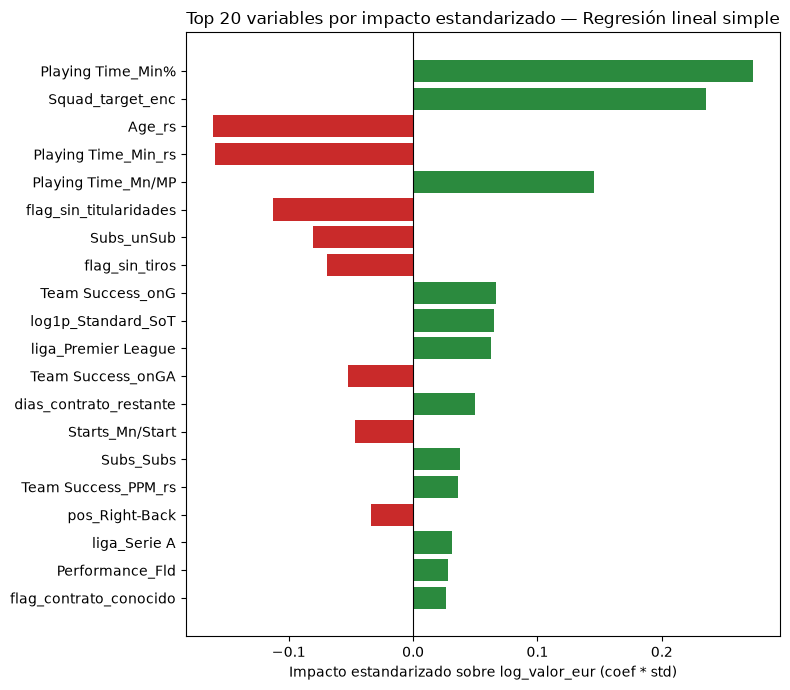

In [9]:
import matplotlib.pyplot as plt

top20 = coef_df.head(20).iloc[::-1]
colors = ["#2b8a3e" if v > 0 else "#c92a2a" for v in top20["impacto_std"]]

fig, ax = plt.subplots(figsize=(8, 7))
ax.barh(top20["feature"], top20["impacto_std"], color=colors)
ax.set_xlabel("Impacto estandarizado sobre log_valor_eur (coef * std)")
ax.set_title("Top 20 variables por impacto estandarizado — Regresión lineal simple")
ax.axvline(0, color="black", linewidth=0.8)
plt.tight_layout()
plt.show()

## 5. Residuos en test

Trabajamos con el test (no train), que es el que refleja error real de generalización. `residuo = real - predicho`: positivo es que subestimamos al jugador, negativo que lo sobreestimamos.

Miramos tres cosas: si el error tiene algún patrón contra el valor predicho, si los residuos se distribuyen normal o no, y cuáles son los jugadores donde más se equivoca el modelo.

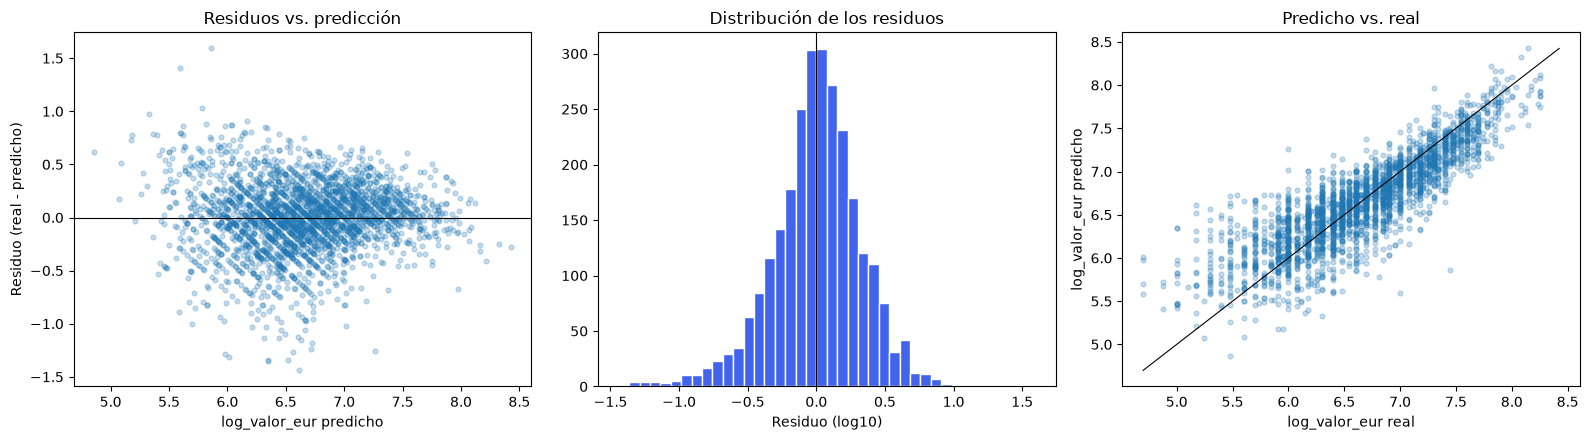

Media del residuo:    -0.0002
Desv. std del residuo: 0.3260
Asimetría (skew):      -0.4126


In [10]:
residuos_test = y_test.values - pred_test

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

axes[0].scatter(pred_test, residuos_test, alpha=0.25, s=12)
axes[0].axhline(0, color="black", linewidth=0.8)
axes[0].set_xlabel("log_valor_eur predicho")
axes[0].set_ylabel("Residuo (real - predicho)")
axes[0].set_title("Residuos vs. predicción")

axes[1].hist(residuos_test, bins=40, color="#4263eb", edgecolor="white")
axes[1].axvline(0, color="black", linewidth=0.8)
axes[1].set_xlabel("Residuo (log10)")
axes[1].set_title("Distribución de los residuos")

axes[2].scatter(y_test, pred_test, alpha=0.25, s=12)
lims = [min(y_test.min(), pred_test.min()), max(y_test.max(), pred_test.max())]
axes[2].plot(lims, lims, color="black", linewidth=0.8)
axes[2].set_xlabel("log_valor_eur real")
axes[2].set_ylabel("log_valor_eur predicho")
axes[2].set_title("Predicho vs. real")

plt.tight_layout()
plt.show()

print(f"Media del residuo:    {residuos_test.mean():.4f}")
print(f"Desv. std del residuo: {residuos_test.std():.4f}")
print(f"Asimetría (skew):      {pd.Series(residuos_test).skew():.4f}")

In [11]:
resultados_test = pd.DataFrame({
    "Player": df_test["Player"].values,
    "valor_eur_real": df_test["valor_eur"].values,
    "valor_eur_pred": 10 ** pred_test,
    "residuo_log10": residuos_test,
})

print("Top 10 más SUBVALORADOS por el modelo (predijo mucho menos que el valor real):")
display(resultados_test.sort_values("residuo_log10", ascending=False).head(10))

print("\nTop 10 más SOBREVALORADOS por el modelo (predijo mucho más que el valor real):")
display(resultados_test.sort_values("residuo_log10", ascending=True).head(10))

Top 10 más SUBVALORADOS por el modelo (predijo mucho menos que el valor real):


,Player,valor_eur_real,valor_eur_pred,residuo_log10
123,Marc Cucurella,28000000.0,7.165790e+05,1.591894
604,Antonín Barák,10000000.0,3.911522e+05,1.407654
1890,Jordan Lotomba,6500000.0,6.035245e+05,1.032218
512,Sada Thioub,2000000.0,2.139747e+05,0.970668
1221,Tiago Djaló,12000000.0,1.468381e+06,0.912342
1281,Thorgan Hazard,5000000.0,6.565834e+05,0.881680
2519,Frank Onyeka,8000000.0,1.067920e+06,0.874551
767,Sergio Herrera,8000000.0,1.084017e+06,0.868054
207,Etienne Green,7000000.0,9.592140e+05,0.863183
1652,Mohamed Bamba,3000000.0,4.169624e+05,0.857024



Top 10 más SOBREVALORADOS por el modelo (predijo mucho más que el valor real):


,Player,valor_eur_real,valor_eur_pred,residuo_log10
2439,Tommaso Macchioni,150000.0,4.126876e+06,-1.439530
1418,Finley Munroe,100000.0,2.244234e+06,-1.351068
1083,Nabil Aberdin,100000.0,2.212492e+06,-1.344882
1784,Jake Evans,150000.0,3.317484e+06,-1.344718
1795,Rayan Fofana,50000.0,1.032106e+06,-1.314754
1759,Kembo Diliwidi,50000.0,9.567723e+05,-1.281839
1335,Yoel Lago,200000.0,3.671776e+06,-1.263846
1185,Bobby Clark,1000000.0,1.817426e+07,-1.259457
478,Ellis Simms,300000.0,5.181462e+06,-1.237331
665,Bobby Clark,350000.0,5.327630e+06,-1.182466


## 6. Ridge y Lasso

Los coeficientes mostraron el síntoma típico de multicolinealidad: el bloque de "tiempo de juego" (4 variables parecidas) tenía signos contradictorios entre sí. Ridge debería estabilizarlos repartiendo el peso; Lasso puede directamente llevar algunos a cero -- justo lo que conviene cuando sobran variables redundantes.

A diferencia de OLS, Ridge/Lasso sí son sensibles a la escala, así que estandarizamos las features (ajustado solo con train) antes de entrenar. El `alpha` de cada uno se elige por validación cruzada, no a mano.

In [12]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [13]:
from sklearn.linear_model import RidgeCV

alphas_ridge = np.logspace(-2, 4, 100)
ridge = RidgeCV(alphas=alphas_ridge, cv=5)
ridge.fit(X_train_scaled, y_train)

pred_train_ridge = ridge.predict(X_train_scaled)
pred_test_ridge = ridge.predict(X_test_scaled)

print(f"Mejor alpha (Ridge, CV): {ridge.alpha_:.3f}\n")
evaluar(y_train, pred_train_ridge, "Train - Ridge")
evaluar(y_test, pred_test_ridge, "Test - Ridge")

Mejor alpha (Ridge, CV): 9.326

--- Train - Ridge ---
R2 (log10):   0.727
RMSE (log10): 0.327
MAE (log10):  0.245
MAE (EUR):    4,489,060
MAPE (EUR):   78.8%

--- Test - Ridge ---
R2 (log10):   0.731
RMSE (log10): 0.326
MAE (log10):  0.245
MAE (EUR):    4,833,398
MAPE (EUR):   77.7%



In [14]:
from sklearn.linear_model import LassoCV

lasso = LassoCV(alphas=100, cv=5, random_state=42, max_iter=20000)
lasso.fit(X_train_scaled, y_train)

pred_train_lasso = lasso.predict(X_train_scaled)
pred_test_lasso = lasso.predict(X_test_scaled)

n_zero = (lasso.coef_ == 0).sum()
print(f"Mejor alpha (Lasso, CV): {lasso.alpha_:.5f}")
print(f"Coeficientes llevados a cero: {n_zero} de {len(lasso.coef_)}\n")
evaluar(y_train, pred_train_lasso, "Train - Lasso")
evaluar(y_test, pred_test_lasso, "Test - Lasso")

Mejor alpha (Lasso, CV): 0.00039
Coeficientes llevados a cero: 3 de 60

--- Train - Lasso ---
R2 (log10):   0.727
RMSE (log10): 0.327
MAE (log10):  0.245
MAE (EUR):    4,485,835
MAPE (EUR):   78.8%

--- Test - Lasso ---
R2 (log10):   0.731
RMSE (log10): 0.326
MAE (log10):  0.245
MAE (EUR):    4,839,403
MAPE (EUR):   77.5%



### 6.1 ¿Qué le hizo Lasso al bloque de tiempo de juego?

In [15]:
comparacion_coef = pd.DataFrame({
    "feature": feature_cols,
    # coeficiente OLS reescalado (coef * std) para que sea comparable con Ridge/Lasso,
    # que sí se entrenaron sobre features estandarizadas (ver sección 4)
    "OLS_std": lr.coef_ * X_train.std().values,
    "Ridge": ridge.coef_,
    "Lasso": lasso.coef_,
})

playing_time_vars = ["Playing Time_Min%", "Playing Time_Mn/MP", "Playing Time_Min_rs", "Starts_Mn/Start"]
print("Bloque de tiempo de juego (los tres, en la misma escala: efecto por 1 desv. estándar):")
display(comparacion_coef[comparacion_coef["feature"].isin(playing_time_vars)])

vars_eliminadas = comparacion_coef.loc[comparacion_coef["Lasso"] == 0, "feature"].tolist()
print(f"\nVariables que Lasso llevó a cero ({len(vars_eliminadas)}):")
print(vars_eliminadas)

Bloque de tiempo de juego (los tres, en la misma escala: efecto por 1 desv. estándar):


,feature,OLS_std,Ridge,Lasso
14,Playing Time_Mn/MP,0.145281,0.142159,0.130473
15,Playing Time_Min%,0.273293,0.196352,0.109622
16,Starts_Mn/Start,-0.046939,-0.042679,-0.025310
33,Playing Time_Min_rs,-0.159502,-0.083767,-0.000000



Variables que Lasso llevó a cero (3):
['Performance_Off', 'altura_m_rs', 'Playing Time_Min_rs']


### 6.2 Comparación final: OLS vs. Ridge vs. Lasso

In [16]:
def metricas(y_true_log, y_pred_log):
    y_true_eur, y_pred_eur = 10 ** y_true_log, 10 ** y_pred_log
    return {
        "R2 (log10)": r2_score(y_true_log, y_pred_log),
        "RMSE (log10)": mean_squared_error(y_true_log, y_pred_log) ** 0.5,
        "MAE (EUR)": mean_absolute_error(y_true_eur, y_pred_eur),
        "MAPE (EUR) %": (np.abs((y_true_eur - y_pred_eur) / y_true_eur)).mean() * 100,
    }

resumen = pd.DataFrame({
    "OLS": metricas(y_test, pred_test),
    "Ridge": metricas(y_test, pred_test_ridge),
    "Lasso": metricas(y_test, pred_test_lasso),
}).T
resumen

,R2 (log10),RMSE (log10),MAE (EUR),MAPE (EUR) %
OLS,0.730449,0.325968,4.826864e+06,77.803195
Ridge,0.730762,0.325779,4.833398e+06,77.655476
Lasso,0.731045,0.325608,4.839403e+06,77.514974


### 6.3 ¿Se equivocan igual los tres modelos lineales?

Antes de pasar a árboles, vale la pena ver si OLS/Ridge/Lasso fallan con los mismos jugadores (entonces el problema no es la regularización, es que la relación no es lineal) o cada uno falla distinto.

(Recuperamos `posicion_tm`, `Comp` y `Age` desde `fbref_tm_eda.parquet` solo para poder segmentar este análisis -- no se usan como feature, ya están convertidas en dummies/`_rs`.)

In [17]:
df_eda_ref = pd.read_parquet("../data/processed/fbref_tm_eda.parquet")[
    ["player_id", "saison_id", "posicion_tm", "Comp", "Age"]
]
# fbref_tm_eda.parquet aun no pasa por el dedup de club_coincide de la seccion 2.1
# (eso lo resuelve 03-ingenieria_variables.ipynb) -- para este analisis de error solo
# necesitamos una etiqueta descriptiva, asi que basta con quedarnos con una fila por
# (player_id, saison_id), no hace falta repetir la logica de club_coincide.
df_eda_ref = df_eda_ref.drop_duplicates(subset=["player_id", "saison_id"], keep="first")

errores = df_test[["Player", "player_id", "saison_id", "valor_eur"]].copy()
errores = errores.merge(df_eda_ref, on=["player_id", "saison_id"], how="left")
assert len(errores) == len(df_test), "el merge no debe cambiar el numero de filas"

errores["pred_OLS"] = 10 ** pred_test
errores["pred_Ridge"] = 10 ** pred_test_ridge
errores["pred_Lasso"] = 10 ** pred_test_lasso

for modelo in ["OLS", "Ridge", "Lasso"]:
    errores[f"residuo_{modelo}"] = y_test.values - np.log10(errores[f"pred_{modelo}"])

errores[["residuo_OLS", "residuo_Ridge", "residuo_Lasso"]].describe()

,residuo_OLS,residuo_Ridge,residuo_Lasso
count,2671.000000,2671.000000,2671.000000
mean,-0.000179,0.000021,0.000283
std,0.326029,0.325840,0.325668
min,-1.439530,-1.435323,-1.431665
25%,-0.177146,-0.178281,-0.179335
50%,0.015292,0.013871,0.014739
75%,0.197156,0.195017,0.195182
max,1.591894,1.595899,1.601769


In [18]:
corr_residuos = errores[["residuo_OLS", "residuo_Ridge", "residuo_Lasso"]].corr()
print("Correlación entre los residuos (log10) de los 3 modelos:")
corr_residuos

Correlación entre los residuos (log10) de los 3 modelos:


,residuo_OLS,residuo_Ridge,residuo_Lasso
residuo_OLS,1.000000,0.999898,0.999321
residuo_Ridge,0.999898,1.000000,0.999678
residuo_Lasso,0.999321,0.999678,1.000000


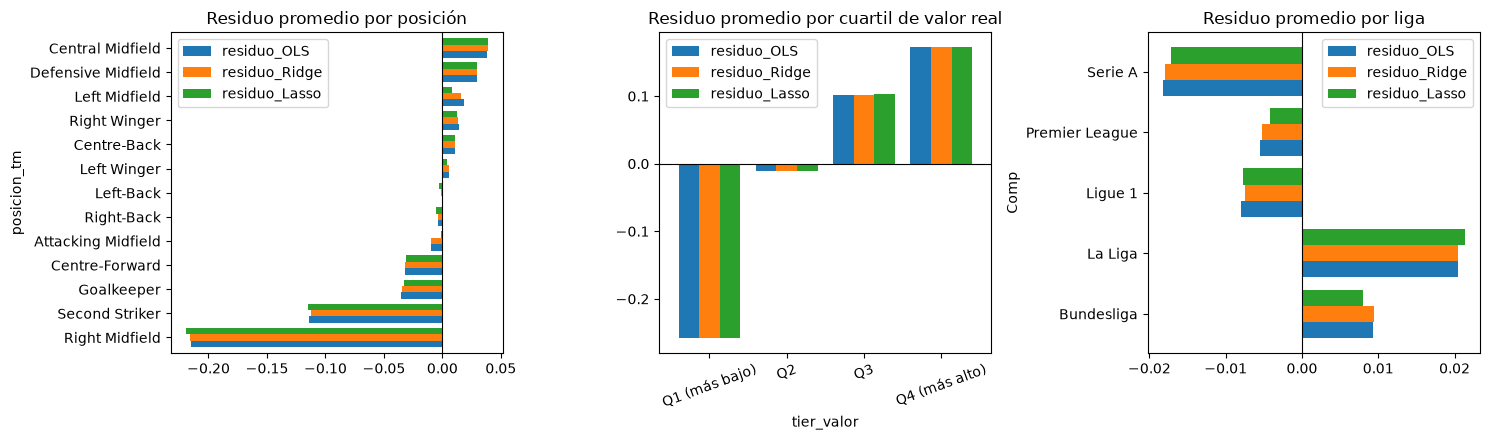

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

resumen_pos = errores.groupby("posicion_tm", observed=True)[["residuo_OLS", "residuo_Ridge", "residuo_Lasso"]].mean()
resumen_pos = resumen_pos.reindex(resumen_pos["residuo_OLS"].sort_values().index)
resumen_pos.plot(kind="barh", ax=axes[0], width=0.8)
axes[0].axvline(0, color="black", lw=0.8)
axes[0].set_title("Residuo promedio por posición")

errores["tier_valor"] = pd.qcut(errores["valor_eur"], 4, labels=["Q1 (más bajo)", "Q2", "Q3", "Q4 (más alto)"])
resumen_tier = errores.groupby("tier_valor", observed=True)[["residuo_OLS", "residuo_Ridge", "residuo_Lasso"]].mean()
resumen_tier.plot(kind="bar", ax=axes[1], width=0.8, rot=20)
axes[1].axhline(0, color="black", lw=0.8)
axes[1].set_title("Residuo promedio por cuartil de valor real")

resumen_liga = errores.groupby("Comp", observed=True)[["residuo_OLS", "residuo_Ridge", "residuo_Lasso"]].mean()
resumen_liga.plot(kind="barh", ax=axes[2], width=0.8)
axes[2].axvline(0, color="black", lw=0.8)
axes[2].set_title("Residuo promedio por liga")

plt.tight_layout()
plt.show()

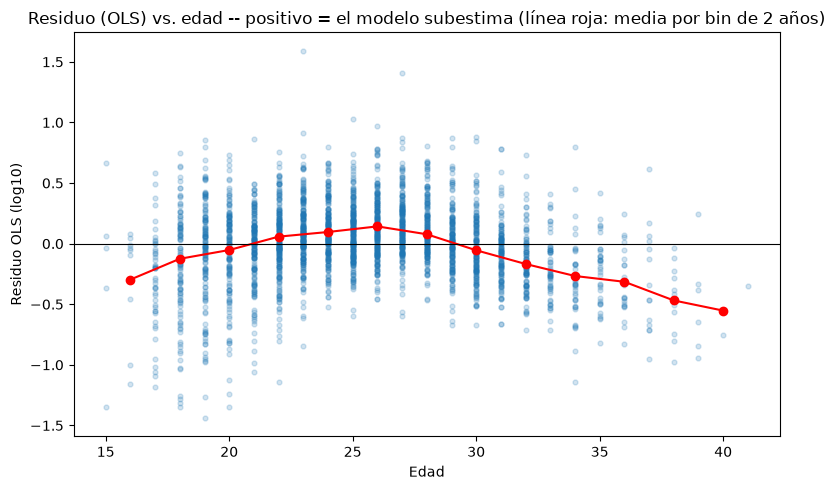

In [20]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(errores["Age"], errores["residuo_OLS"], alpha=0.2, s=12)

edad_bin_medio = errores.groupby(pd.cut(errores["Age"], bins=range(15, 42, 2)), observed=True)["residuo_OLS"].mean()
ax.plot([iv.mid for iv in edad_bin_medio.index], edad_bin_medio.values, color="red", marker="o", lw=1.5)

ax.axhline(0, color="black", lw=0.8)
ax.set_xlabel("Edad")
ax.set_ylabel("Residuo OLS (log10)")
ax.set_title("Residuo (OLS) vs. edad -- positivo = el modelo subestima (línea roja: media por bin de 2 años)")
plt.tight_layout()
plt.show()

In [21]:
errores["residuo_promedio"] = errores[["residuo_OLS", "residuo_Ridge", "residuo_Lasso"]].mean(axis=1)
cols_mostrar = ["Player", "posicion_tm", "Comp", "Age", "valor_eur",
                "pred_OLS", "pred_Ridge", "pred_Lasso", "residuo_promedio"]

print("Top 10 más SUBESTIMADOS -- consenso de los 3 modelos lineales:")
display(errores.sort_values("residuo_promedio", ascending=False).head(10)[cols_mostrar])

print("\nTop 10 más SOBREESTIMADOS -- consenso de los 3 modelos lineales:")
display(errores.sort_values("residuo_promedio").head(10)[cols_mostrar])

Top 10 más SUBESTIMADOS -- consenso de los 3 modelos lineales:


,Player,posicion_tm,Comp,Age,valor_eur,pred_OLS,pred_Ridge,pred_Lasso,residuo_promedio
123,Marc Cucurella,Left-Back,La Liga,23.0,28000000.0,7.165790e+05,7.100008e+05,7.004690e+05,1.596521
604,Antonín Barák,Attacking Midfield,Serie A,27.0,10000000.0,3.911522e+05,3.871834e+05,3.778958e+05,1.414122
1890,Jordan Lotomba,Right-Back,Ligue 1,25.0,6500000.0,6.035245e+05,6.071158e+05,6.142451e+05,1.028811
512,Sada Thioub,Right Winger,Ligue 1,26.0,2000000.0,2.139747e+05,2.161230e+05,2.204542e+05,0.964903
1221,Tiago Djaló,Centre-Back,Serie A,23.0,12000000.0,1.468381e+06,1.457348e+06,1.452901e+06,0.914969
2519,Frank Onyeka,Central Midfield,Premier League,27.0,8000000.0,1.067920e+06,1.059486e+06,1.044311e+06,0.878935
1281,Thorgan Hazard,Attacking Midfield,Bundesliga,30.0,5000000.0,6.565834e+05,6.691884e+05,6.828985e+05,0.873239
767,Sergio Herrera,Goalkeeper,La Liga,29.0,8000000.0,1.084017e+06,1.085770e+06,1.082074e+06,0.868080
207,Etienne Green,Goalkeeper,Ligue 1,21.0,7000000.0,9.592140e+05,9.730806e+05,9.857942e+05,0.857148
1652,Mohamed Bamba,Defensive Midfield,Ligue 1,19.0,3000000.0,4.169624e+05,4.195719e+05,4.279787e+05,0.852346



Top 10 más SOBREESTIMADOS -- consenso de los 3 modelos lineales:


,Player,posicion_tm,Comp,Age,valor_eur,pred_OLS,pred_Ridge,pred_Lasso,residuo_promedio
2439,Tommaso Macchioni,Centre-Back,Serie A,19.0,150000.0,4.126876e+06,4.087087e+06,4.052814e+06,-1.435506
1418,Finley Munroe,Left-Back,Premier League,18.0,100000.0,2.244234e+06,2.224682e+06,2.225918e+06,-1.348615
1083,Nabil Aberdin,Centre-Back,La Liga,20.0,100000.0,2.212492e+06,2.192090e+06,2.179113e+06,-1.341340
1784,Jake Evans,Centre-Forward,Premier League,15.0,150000.0,3.317484e+06,3.284914e+06,3.244875e+06,-1.340086
1795,Rayan Fofana,Centre-Forward,Ligue 1,18.0,50000.0,1.032106e+06,1.038046e+06,1.050941e+06,-1.318203
1759,Kembo Diliwidi,Left Winger,Ligue 1,18.0,50000.0,9.567723e+05,9.652308e+05,9.875424e+05,-1.287695
1335,Yoel Lago,Centre-Back,La Liga,19.0,200000.0,3.671776e+06,3.637414e+06,3.613668e+06,-1.260176
1185,Bobby Clark,Central Midfield,Premier League,18.0,1000000.0,1.817426e+07,1.804988e+07,1.782568e+07,-1.255659
478,Ellis Simms,Centre-Forward,Premier League,20.0,300000.0,5.181462e+06,5.109468e+06,5.025504e+06,-1.230881
665,Bobby Clark,Central Midfield,Premier League,17.0,350000.0,5.327630e+06,5.288326e+06,5.283486e+06,-1.180190


### 6.4 ¿El sesgo con canteranos es por `Squad_target_enc`? Probamos sacarlo -- no

Reentrenamos los 5 modelos sin `Squad_target_enc`, pensando que el prestigio del club explicaba el sesgo hacia canteranos de clubes grandes. Empeoró los 5, sin excepción:

| Modelo | R² con → sin | MAPE con → sin |
|---|---|---|
| OLS | 0.731 → 0.689 | 78.0% → 84.6% |
| Ridge | 0.731 → 0.689 | 77.9% → 84.6% |
| Lasso | 0.731 → 0.690 | 77.7% → 84.1% |
| Random Forest | 0.812 → 0.774 | 57.3% → 66.1% |
| XGBoost | 0.831 → 0.803 | 53.2% → 59.5% |

`Squad_target_enc` aporta señal real (el contexto del club sí explica valor de mercado), así que la conservamos. El sesgo con jóvenes de clubes grandes queda como limitación conocida, no resuelta.

## 7. Random Forest

Los tres lineales llegaron al mismo techo (R² ≈ 0.695) -- el problema no era la multicolinealidad, era que un modelo lineal no puede capturar los efectos no lineales que vimos en los residuos (piso de mercado para jugadores marginales, prima de reputación para superestrellas). Random Forest sí puede, y de paso no necesita features escaladas.

Primero un modelo base sin ajustar nada, usando `oob_score` como referencia extra.

In [22]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=500,
    random_state=42,
    n_jobs=-1,
    oob_score=True,
)
rf.fit(X_train, y_train)

pred_train_rf = rf.predict(X_train)
pred_test_rf = rf.predict(X_test)

print(f"OOB score (R2): {rf.oob_score_:.3f}\n")
evaluar(y_train, pred_train_rf, "Train - Random Forest")
evaluar(y_test, pred_test_rf, "Test - Random Forest")

OOB score (R2): 0.815

--- Train - Random Forest ---
R2 (log10):   0.975
RMSE (log10): 0.099
MAE (log10):  0.075
MAE (EUR):    1,560,383
MAPE (EUR):   17.5%

--- Test - Random Forest ---
R2 (log10):   0.810
RMSE (log10): 0.274
MAE (log10):  0.207
MAE (EUR):    4,206,133
MAPE (EUR):   57.6%



Salto grande (R² test 0.695 → 0.798), pero el modelo base está sobreajustado (train 0.973 vs. test 0.798). El `oob_score_` (0.797) confirma que el número de test no es casualidad del split, pero conviene limitar la profundidad de los árboles para cerrar esa brecha. Buscamos los hiperparámetros por validación cruzada sobre el train.

In [23]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    "n_estimators": [300, 500, 800],
    "max_depth": [8, 12, 16, 20, None],
    "min_samples_leaf": [1, 2, 4, 8],
    "max_features": ["sqrt", 0.5, 0.7, 1.0],
}

rf_search = RandomizedSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    param_distributions=param_dist,
    n_iter=25,
    cv=5,
    scoring="r2",
    random_state=42,
    n_jobs=-1,
)
rf_search.fit(X_train, y_train)

print("Mejores hiperparámetros:", rf_search.best_params_)
print(f"R2 CV (train): {rf_search.best_score_:.3f}\n")

rf_tuned = rf_search.best_estimator_
pred_train_rf_tuned = rf_tuned.predict(X_train)
pred_test_rf_tuned = rf_tuned.predict(X_test)

evaluar(y_train, pred_train_rf_tuned, "Train - RF tuned")
evaluar(y_test, pred_test_rf_tuned, "Test - RF tuned")

/home/diego/diplomado/.venv312/lib/python3.12/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/diego/diplomado/.venv312/lib/python3.12/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/diego/diplomado/.venv312/lib/python3.12/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/diego/diplomado/.venv312/lib/python3.12/sit

/home/diego/diplomado/.venv312/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Mejores hiperparámetros: {'n_estimators': 800, 'min_samples_leaf': 2, 'max_features': 0.7, 'max_depth': 16}
R2 CV (train): 0.807



--- Train - RF tuned ---
R2 (log10):   0.962
RMSE (log10): 0.122
MAE (log10):  0.090
MAE (EUR):    1,821,375
MAPE (EUR):   21.4%

--- Test - RF tuned ---
R2 (log10):   0.812
RMSE (log10): 0.272
MAE (log10):  0.206
MAE (EUR):    4,194,164
MAPE (EUR):   57.2%



### 7.1 Importancia de variables (Random Forest ajustado)

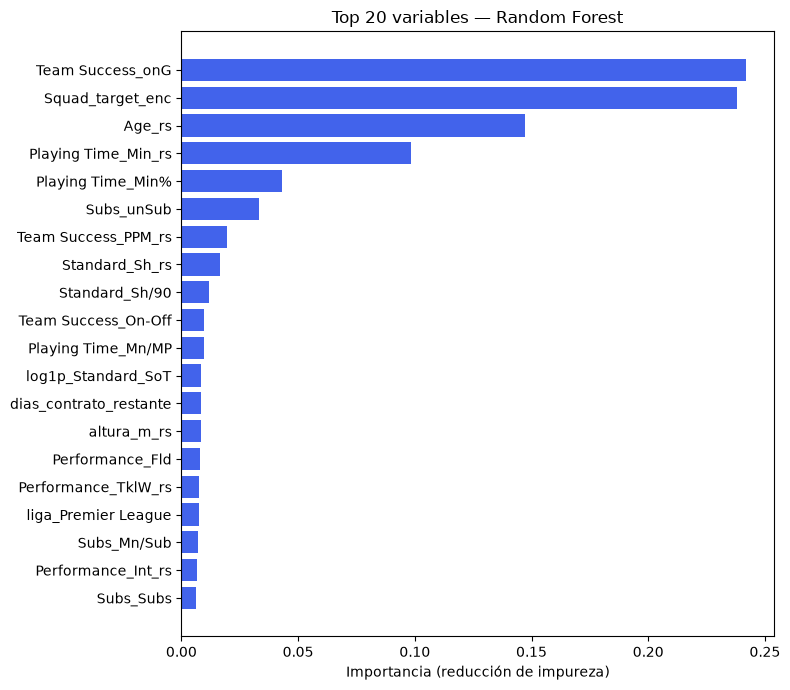

,feature,importancia
0,Team Success_onG,0.241831
1,Squad_target_enc,0.238151
2,Age_rs,0.147407
3,Playing Time_Min_rs,0.098273
4,Playing Time_Min%,0.043215
5,Subs_unSub,0.033270
6,Team Success_PPM_rs,0.019661
7,Standard_Sh_rs,0.016631
8,Standard_Sh/90,0.011771
9,Team Success_On-Off,0.009728


In [24]:
importancias = pd.DataFrame({
    "feature": feature_cols,
    "importancia": rf_tuned.feature_importances_,
}).sort_values("importancia", ascending=False).reset_index(drop=True)

top20_rf = importancias.head(20).iloc[::-1]

fig, ax = plt.subplots(figsize=(8, 7))
ax.barh(top20_rf["feature"], top20_rf["importancia"], color="#4263eb")
ax.set_xlabel("Importancia (reducción de impureza)")
ax.set_title("Top 20 variables — Random Forest")
plt.tight_layout()
plt.show()

importancias.head(15)

### 7.2 ¿Random Forest arregla el piso de mercado y la prima de superestrella?

Repetimos el diagnóstico de residuos de la sección 5, y de paso miramos qué predice ahora para "Rodri" y "Daniel Rodriguez" -- los dos casos más raros que nos habían salido con la regresión lineal.

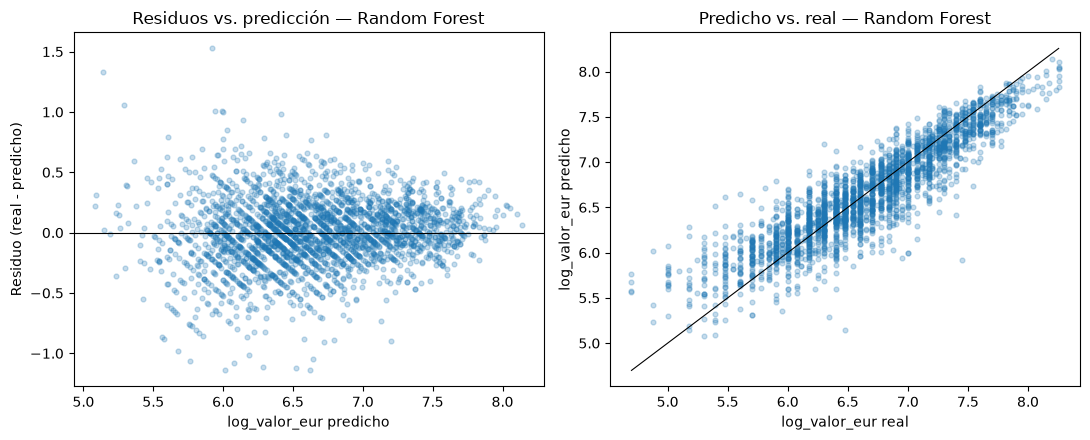

Asimetría (skew) residuos RF: -0.1281  (OLS era -0.40)

Casos puntuales (comparar con la sección 5):


,Player,valor_eur_real,valor_eur_pred


In [25]:
residuos_test_rf = y_test.values - pred_test_rf_tuned

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

axes[0].scatter(pred_test_rf_tuned, residuos_test_rf, alpha=0.25, s=12)
axes[0].axhline(0, color="black", linewidth=0.8)
axes[0].set_xlabel("log_valor_eur predicho")
axes[0].set_ylabel("Residuo (real - predicho)")
axes[0].set_title("Residuos vs. predicción — Random Forest")

axes[1].scatter(y_test, pred_test_rf_tuned, alpha=0.25, s=12)
lims = [min(y_test.min(), pred_test_rf_tuned.min()), max(y_test.max(), pred_test_rf_tuned.max())]
axes[1].plot(lims, lims, color="black", linewidth=0.8)
axes[1].set_xlabel("log_valor_eur real")
axes[1].set_ylabel("log_valor_eur predicho")
axes[1].set_title("Predicho vs. real — Random Forest")

plt.tight_layout()
plt.show()

print(f"Asimetría (skew) residuos RF: {pd.Series(residuos_test_rf).skew():.4f}  (OLS era -0.40)\n")

resultados_test_rf = pd.DataFrame({
    "Player": df_test["Player"].values,
    "valor_eur_real": df_test["valor_eur"].values,
    "valor_eur_pred": 10 ** pred_test_rf_tuned,
})
print("Casos puntuales (comparar con la sección 5):")
display(resultados_test_rf[resultados_test_rf["Player"].isin(["Rodri", "Daniel Rodriguez"])])

## 8. XGBoost

A diferencia de Random Forest (árboles independientes promediados), XGBoost los construye en serie -- cada árbol nuevo corrige lo que dejó mal el anterior. Suele generalizar mejor con menos árboles, pero es más sensible a los hiperparámetros (sobre todo `learning_rate`). Mismo criterio que antes: hiperparámetros por validación cruzada sobre el train.

In [26]:
from xgboost import XGBRegressor

param_dist_xgb = {
    "n_estimators": [200, 400, 600, 900],
    "max_depth": [3, 4, 5, 6, 8],
    "learning_rate": [0.01, 0.03, 0.05, 0.1, 0.2],
    "subsample": [0.6, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0],
    "reg_alpha": [0, 0.1, 1, 5],
    "reg_lambda": [1, 5, 10],
}

xgb_search = RandomizedSearchCV(
    XGBRegressor(random_state=42, n_jobs=1, objective="reg:squarederror"),
    param_distributions=param_dist_xgb,
    n_iter=25,
    cv=5,
    scoring="r2",
    random_state=42,
    n_jobs=-1,
)
xgb_search.fit(X_train, y_train)

print("Mejores hiperparámetros:", xgb_search.best_params_)
print(f"R2 CV (train): {xgb_search.best_score_:.3f}\n")

xgb_best = xgb_search.best_estimator_
pred_train_xgb = xgb_best.predict(X_train)
pred_test_xgb = xgb_best.predict(X_test)

evaluar(y_train, pred_train_xgb, "Train - XGBoost")
evaluar(y_test, pred_test_xgb, "Test - XGBoost")

/home/diego/diplomado/.venv312/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Mejores hiperparámetros: {'subsample': 0.8, 'reg_lambda': 10, 'reg_alpha': 5, 'n_estimators': 600, 'max_depth': 6, 'learning_rate': 0.05, 'colsample_bytree': 0.8}
R2 CV (train): 0.824

--- Train - XGBoost ---
R2 (log10):   0.911
RMSE (log10): 0.187
MAE (log10):  0.141
MAE (EUR):    2,713,626
MAPE (EUR):   35.3%

--- Test - XGBoost ---
R2 (log10):   0.831
RMSE (log10): 0.258
MAE (log10):  0.192
MAE (EUR):    3,839,096
MAPE (EUR):   53.0%



### 8.1 Importancia de variables (XGBoost)

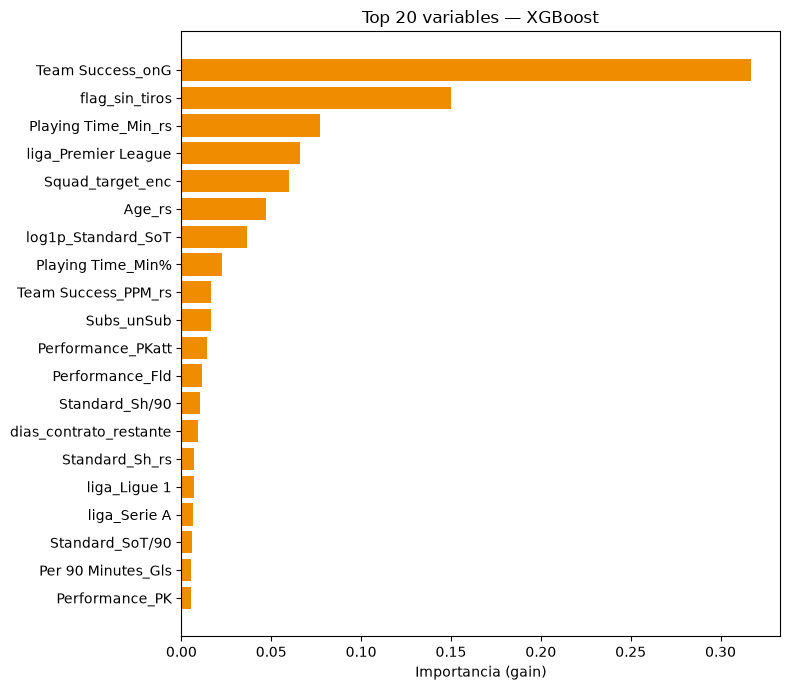

,feature,importancia
0,Team Success_onG,0.317223
1,flag_sin_tiros,0.150002
2,Playing Time_Min_rs,0.077087
3,liga_Premier League,0.065920
4,Squad_target_enc,0.059817
5,Age_rs,0.047219
6,log1p_Standard_SoT,0.036486
7,Playing Time_Min%,0.022520
8,Team Success_PPM_rs,0.016700
9,Subs_unSub,0.016356


In [27]:
importancias_xgb = pd.DataFrame({
    "feature": feature_cols,
    "importancia": xgb_best.feature_importances_,
}).sort_values("importancia", ascending=False).reset_index(drop=True)

top20_xgb = importancias_xgb.head(20).iloc[::-1]

fig, ax = plt.subplots(figsize=(8, 7))
ax.barh(top20_xgb["feature"], top20_xgb["importancia"], color="#f08c00")
ax.set_xlabel("Importancia (gain)")
ax.set_title("Top 20 variables — XGBoost")
plt.tight_layout()
plt.show()

importancias_xgb.head(15)

## 9. Comparación final de todos los modelos (test)

In [28]:
resumen_final = pd.DataFrame({
    "OLS": metricas(y_test, pred_test),
    "Ridge": metricas(y_test, pred_test_ridge),
    "Lasso": metricas(y_test, pred_test_lasso),
    "Random Forest": metricas(y_test, pred_test_rf_tuned),
    "XGBoost": metricas(y_test, pred_test_xgb),
}).T
resumen_final

,R2 (log10),RMSE (log10),MAE (EUR),MAPE (EUR) %
OLS,0.730449,0.325968,4.826864e+06,77.803195
Ridge,0.730762,0.325779,4.833398e+06,77.655476
Lasso,0.731045,0.325608,4.839403e+06,77.514974
Random Forest,0.811850,0.272337,4.194164e+06,57.214438
XGBoost,0.831394,0.257805,3.839096e+06,52.952701


## 10. Del mejor modelo a la decisión de producción

Por métrica pura, XGBoost gana (ver la comparación arriba). Pero el modelo que termina sirviendo la app **no es XGBoost, es Lasso** -- decisión que se toma después, en `scripts/build_model_artifacts.py`: los coeficientes lineales dan una explicación exacta y aditiva de cada predicción, sin aproximar nada, algo que con un ensemble de árboles requeriría SHAP. Ese script reentrena sobre el 100% de los datos (acá el split era solo para medir generalización), agrega percentiles y el clustering de arquetipo, y deja todo listo en `models/` + `dataset.parquet` para que lo sirva `app/`. El detalle completo de esta decisión está en `AGENTS.md`.

### 10.1 Coeficientes del Lasso servido en producción

Este gráfico no usa el `lasso` de la sección 6 (entrenado solo con el 80% de train), sino el modelo que realmente sirve la app: el que `scripts/build_model_artifacts.py` reentrena sobre el 100% de los datos y guarda en `models/`. Como el Lasso se entrena sobre variables estandarizadas, sus coeficientes ya son comparables entre sí: cada uno es el efecto de 1 desviación estándar de la variable sobre `log_valor_eur`.

In [ ]:
import joblib

lasso_prod = joblib.load("../models/lasso_model.joblib")
feature_cols_prod = joblib.load("../models/feature_cols.joblib")

coef_prod = pd.DataFrame({
    "feature": feature_cols_prod,
    "coef": lasso_prod.coef_,
}).sort_values("coef", key=np.abs, ascending=False).reset_index(drop=True)

top15_prod = coef_prod.head(15).iloc[::-1]
colors = ["#2b8a3e" if v > 0 else "#c92a2a" for v in top15_prod["coef"]]

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(top15_prod["feature"], top15_prod["coef"], color=colors)
ax.set_xlabel("Coeficiente sobre log_valor_eur (por 1 desv. estándar)")
ax.set_title("Top 15 variables por coeficiente — Lasso servido en producción")
ax.axvline(0, color="black", linewidth=0.8)
plt.tight_layout()
plt.show()